# PyEO Machine Learning: How to train your machine learning model.

This notebook was developed for pyeo on a Windows computer.

In this notebook, we will create a machine learning model to classify land cover from a satellite image. This is a step that is needed to proceed to a post-classification change detection between different image acquisiton dates.
To train a model, we will need training data. For PyEO, we define training data as pixel-based land surface reflectance values at multiple wavelengths (image bands) and their corresponding 'true' land cover classes from our own visual image interpretation.
The next section below details how to generate this training data by manually delineating polygons using the QGIS software.

# Delineate Sample Areas using QGIS

## Live Demo: Training Sample Delineation

- Prof. Heiko Balzter will show a recorded demo of how to delineate training data in QGIS.

In [ ]:
from IPython.display import HTML
#HTML('<iframe width="1080" height="490" src="https://leicester.cloud.panopto.eu/Panopto/Pages/Viewer.aspx?id=a4568baf-c85d-4fab-b6c4-ac9300ed6ab2" frameborder="0" allowfullscreen></iframe>')

## QGIS Training Data Specification Process Guide
- In the left hand panel of JupyterLab, navigate to `pyeo/models` within your installation directory and right click to download the sample image to your laptop
  - You need the file `composite_T36MYE_20230220T074941_clipped.tif`
- Once downloaded, open the image in QGIS on your laptop
- Add a shapefile layer
- Toggle editing of the shapefile layer
- Add a field which should be integer and named `class`
- Delineate features using the **Add Polygon Feature** tool. It looks like this: ![image](./Create_polygon.PNG) 
- Add training polygons for classes of interest to your shape file. 
- So that we can compare results please train for the following land use classes, using the integer CODE assigned to each in the table below:
  - `Primary Forest` 1; 
  - `Plantation Forest` 2;
  - `Bare Soil` 3;
  - `Crops` 4;
  - `Grassland` 5;
  - `Artificial` 13;
- Save your shapefile to your laptop hard drive
- Use the 'Upload' button to bring your saved shapefile to the folder 'model_dir' within your PyEO installation on SEPAL


## QGIS Tips

- Whilst in QGIS, make sure you have the **Digitizing** and **Advanced Digitizing** toolbars enabled. To do so, click:  
    - View > Toolbars > Tick Digitizing and Advanced Digitizing
- Avoid delineating near the edges of land cover, e.g. at the forest edge adjacent to a road. These edge pixels will capture the variation in land-cover at the sub-pixel level, confusing your classifier. 
- The **Reshape Features** tool, is extremely useful for extending already delineated polygons. Click inside the polygon you want to extend, then click any points outside of the polygon (covering your land cover class of interest), once ready - click inside the polygon to complete the loop, and right click to finish delineation. The tool icon looks like this: ![image](./Reshape_features.PNG)
- Install Google Earth Pro on your PC, https://www.google.com/earth/about/versions/ , which offers very-high resolution satellite imagery, and Google StreetView, to help you understand the land covers you are delineating.
- Install the QGIS plugin, **Send2GE**. This plugin sends your location directly to your installed Google Earth Pro. To do so, click on the Send2GE icon, ![image](./Send2GE.PNG), and then click on the location you want to view in Google Earth Pro.
- When developing models in future you may wish to develop your own choice of Land Cover classes and tailor them to what you want your model to achieve. Listed below is the full list of classes that we have evaluated for our `PyEO` forest alert classifier, but alternative classes may be more appropriate for your needs.

    1. Primary Forest
    2. Plantation Forest
    3. Bare Soil
    4. Crops
    5. Grassland
    6. Open Water
    7. Burn Scar
    8. Cloud
    9. Cloud Shadow
    10. Haze
    11. Sparse Woodland
    12. Dense Woodland
    13. Artificial
    

# Setup: Requirements to use this Notebook

## Check the working directory is set to `pyeo` within your PyEO installation

In [1]:
pwd

'C:\\GIS\\projects\\Amazon_BR163_PyEO\\03_notebooks'

In [2]:
cd C:\GIS\src\pyeo

C:\GIS\src\pyeo


In [3]:
pwd

'C:\\GIS\\src\\pyeo'

## Import the Required Libraries

Before proceeding, let's check that the import statements from pyeo execute correctly. You may get a Windows or IOS warning about patching of GetVirtualMemArray. Let's ignore that for now.

In [4]:
import json
import os
import shutil
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from matplotlib.colors import BoundaryNorm, ListedColormap
from osgeo import gdal, ogr

from pyeo import classification as cls
from pyeo import filesystem_utilities as file_utils

from sklearn import ensemble as ens
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
)

gdal.UseExceptions()

print("Library imports complete")

2026-07-27 21:52:59,994: WARNING: Windows or iOS detected; Patching GetVirtualMemArray. Some functions may not respond as expected.


Library imports complete


## Specify the Model Storage Directory

In [5]:
pyeo_dir = r"C:\GIS\src\pyeo"

In [6]:
os.chdir(pyeo_dir)

In [7]:
pwd

'C:\\GIS\\src\\pyeo'

In [8]:
project_dir = Path(r"C:\GIS\projects\Amazon_BR163_PyEO")

training_dir = project_dir / "04_training"
model_dir = project_dir / "05_model"
log_dir = project_dir / "11_logs"
export_dir = training_dir / "pyeo_exports"

for folder in (training_dir, model_dir, log_dir, export_dir):
    folder.mkdir(parents=True, exist_ok=True)

os.chdir(pyeo_dir)

print("Project directory:", project_dir)
print("Training directory:", training_dir)
print("Model directory:", model_dir)
print("Log directory:", log_dir)
print("PyEO vector export directory:", export_dir)

Project directory: C:\GIS\projects\Amazon_BR163_PyEO
Training directory: C:\GIS\projects\Amazon_BR163_PyEO\04_training
Model directory: C:\GIS\projects\Amazon_BR163_PyEO\05_model
Log directory: C:\GIS\projects\Amazon_BR163_PyEO\11_logs
PyEO vector export directory: C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports


- TIP: Use the File Browser to check your new folder now exists

## Initialise Logging Output

- When running `PyEO`, we record our processing steps, chosen parameters and other information in a log file (with file ending `.log`).
- If we are ever curious about what `PyEO` has done and when, we can look at the log file.
- Below, we initialise our log file 
- **Note: the .log does not need to exist before running the function**

In [9]:
log_filename = "amazon_model_training.log"
log_path = log_dir / log_filename

log = file_utils.init_log(str(log_path))

log.info("Amazon BR163 model-training notebook started")
log.info("PyEO directory: %s", pyeo_dir)
log.info("Project directory: %s", project_dir)
log.info("Training directory: %s", training_dir)
log.info("Model directory: %s", model_dir)
log.info("Log directory: %s", log_dir)

print("Log initialized:", log_path)

2026-07-27 21:54:37,105: INFO: ---------------------------------------------------------------
2026-07-27 21:54:37,106: INFO: ---                 PROCESSING START                        ---
2026-07-27 21:54:37,107: INFO: ---------------------------------------------------------------
2026-07-27 21:54:37,109: INFO: Amazon BR163 model-training notebook started
2026-07-27 21:54:37,110: INFO: PyEO directory: C:\GIS\src\pyeo
2026-07-27 21:54:37,111: INFO: Project directory: C:\GIS\projects\Amazon_BR163_PyEO
2026-07-27 21:54:37,113: INFO: Training directory: C:\GIS\projects\Amazon_BR163_PyEO\04_training
2026-07-27 21:54:37,114: INFO: Model directory: C:\GIS\projects\Amazon_BR163_PyEO\05_model
2026-07-27 21:54:37,115: INFO: Log directory: C:\GIS\projects\Amazon_BR163_PyEO\11_logs


Log initialized: C:\GIS\projects\Amazon_BR163_PyEO\11_logs\amazon_model_training.log


# Model Training and Classification, Step by Step

- In this section, we will follow the individual steps to extract spectral information from the Sentinel-2 imagery using our training shapefiles, train a Random Forest model on the spectral reflectance values of the land cover classes, and classify a Sentinel-2 image tile.

## Extract Spectral Information from Sentinel-2 Imagery

- Since we have delineated our training polygons, we can now extract the spectral information from the imagery, by running `cls.extract_features_to_csv()` in the cell below.  
- First, specify the paths to the training shapefile, training raster and the out directory.

In [10]:
# Authoritative Amazon input composite
training_raster_path = Path(
    r"C:\GIS\data\Amazon_BR163_PyEO\tile_data\21MYM"
    r"\composite\composite_T21MYM_20240912T140049.tif"
)

# Authoritative Amazon training GeoPackage
training_gpkg_path = training_dir / "amazon_training.gpkg"
training_layer_name = "training_polygons"
validation_layer_name = "validation_polygons"

# Compatibility exports used by the existing PyEO extraction function
training_shapefile_path = export_dir / "training_polygons.shp"
validation_shapefile_path = export_dir / "validation_polygons.shp"

# Model identity
model_name = "amazon_forest_clearing_extratrees"
model_out_filename = f"{model_name}.pkl"

# Extracted pixel-feature tables
training_feature_out_filename = f"{model_name}_training_features.csv"
validation_feature_out_filename = f"{model_name}_validation_features.csv"

training_feature_path = model_dir / training_feature_out_filename
validation_feature_path = model_dir / validation_feature_out_filename
model_path = model_dir / model_out_filename

# Evaluation outputs
confusion_matrix_csv_path = model_dir / f"{model_name}_confusion_matrix.csv"
confusion_matrix_png_path = model_dir / f"{model_name}_confusion_matrix.png"
class_metrics_csv_path = model_dir / f"{model_name}_class_metrics.csv"
classification_report_txt_path = model_dir / f"{model_name}_classification_report.txt"
metadata_json_path = model_dir / f"{model_name}_metadata.json"

# Classified raster output
class_out_path = model_dir / "composite_T21MYM_20240912T140049_full_class.tif"

# Exact composite band order
band_order = [
    "B02_blue",
    "B03_green",
    "B04_red",
    "B08_nir",
]

# Exact model classes
class_names = {
    1: "Forest",
    2: "Clearing",
}

class_values = [1, 2]
target_names = [class_names[value] for value in class_values]

log.info("Amazon file and model configuration loaded")
log.info("Training raster: %s", training_raster_path)
log.info("Training GeoPackage: %s", training_gpkg_path)
log.info("Model output: %s", model_path)
log.info("Band order: %s", band_order)
log.info("Classes: %s", class_names)

print("Amazon model configuration loaded")
print("Training raster:", training_raster_path)
print("Training GeoPackage:", training_gpkg_path)
print("Model output:", model_path)
print("Band order:", band_order)
print("Classes:", class_names)

2026-07-27 21:55:15,945: INFO: Amazon file and model configuration loaded
2026-07-27 21:55:15,946: INFO: Training raster: C:\GIS\data\Amazon_BR163_PyEO\tile_data\21MYM\composite\composite_T21MYM_20240912T140049.tif
2026-07-27 21:55:15,947: INFO: Training GeoPackage: C:\GIS\projects\Amazon_BR163_PyEO\04_training\amazon_training.gpkg
2026-07-27 21:55:15,949: INFO: Model output: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees.pkl
2026-07-27 21:55:15,950: INFO: Band order: ['B02_blue', 'B03_green', 'B04_red', 'B08_nir']
2026-07-27 21:55:15,951: INFO: Classes: {1: 'Forest', 2: 'Clearing'}


Amazon model configuration loaded
Training raster: C:\GIS\data\Amazon_BR163_PyEO\tile_data\21MYM\composite\composite_T21MYM_20240912T140049.tif
Training GeoPackage: C:\GIS\projects\Amazon_BR163_PyEO\04_training\amazon_training.gpkg
Model output: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees.pkl
Band order: ['B02_blue', 'B03_green', 'B04_red', 'B08_nir']
Classes: {1: 'Forest', 2: 'Clearing'}


### Create `out_folder` if it does not exist

In [11]:
for folder in (model_dir, log_dir, export_dir):
    folder.mkdir(parents=True, exist_ok=True)

print("Required output folders exist")

Required output folders exist


### Run `extract_features_to_csv`

Now, we can run the `cls.extract_features_to_csv` function to create a csv file with the spectral signatures for each land cover class. If the column heading of your training shapefile is not `CODE`, substitute the correct column name with the `attribute` argument.

In [12]:
def remove_shapefile(path: Path) -> None:
    """Remove an existing shapefile and its standard sidecar files."""
    for suffix in (
        ".shp",
        ".shx",
        ".dbf",
        ".prj",
        ".cpg",
        ".qpj",
    ):
        sidecar_path = path.with_suffix(suffix)

        if sidecar_path.exists():
            sidecar_path.unlink()


def export_gpkg_layer_to_shapefile(
    gpkg_path: Path,
    layer_name: str,
    output_shapefile: Path,
) -> Path:
    """Export one named GeoPackage layer for PyEO feature extraction."""
    if not gpkg_path.is_file():
        raise FileNotFoundError(
            f"GeoPackage does not exist: {gpkg_path}"
        )

    remove_shapefile(output_shapefile)

    options = gdal.VectorTranslateOptions(
        format="ESRI Shapefile",
        layers=[layer_name],
    )

    result = gdal.VectorTranslate(
        str(output_shapefile),
        str(gpkg_path),
        options=options,
    )

    if result is None:
        raise RuntimeError(
            f"Failed to export layer '{layer_name}' from {gpkg_path}"
        )

    result = None

    if not output_shapefile.is_file():
        raise FileNotFoundError(
            f"Expected shapefile was not created: {output_shapefile}"
        )

    return output_shapefile


training_shapefile_path = export_gpkg_layer_to_shapefile(
    gpkg_path=training_gpkg_path,
    layer_name=training_layer_name,
    output_shapefile=training_shapefile_path,
)

validation_shapefile_path = export_gpkg_layer_to_shapefile(
    gpkg_path=training_gpkg_path,
    layer_name=validation_layer_name,
    output_shapefile=validation_shapefile_path,
)

log.info("Training layer export: %s", training_shapefile_path)
log.info("Validation layer export: %s", validation_shapefile_path)

print("Training export:", training_shapefile_path)
print("Validation export:", validation_shapefile_path)

2026-07-27 21:58:23,803: INFO: Training layer export: C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports\training_polygons.shp
2026-07-27 21:58:23,804: INFO: Validation layer export: C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports\validation_polygons.shp


Training export: C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports\training_polygons.shp
Validation export: C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports\validation_polygons.shp


In [13]:
def inspect_vector(vector_path: Path) -> dict:
    """Return basic QA information for a vector training dataset."""
    dataset = ogr.Open(str(vector_path), 0)

    if dataset is None:
        raise RuntimeError(
            f"Could not open vector dataset: {vector_path}"
        )

    layer = dataset.GetLayer(0)

    if layer is None:
        raise RuntimeError(
            f"No readable layer found in: {vector_path}"
        )

    layer_definition = layer.GetLayerDefn()

    field_names = [
        layer_definition.GetFieldDefn(index).GetName()
        for index in range(layer_definition.GetFieldCount())
    ]

    class_counts = {}

    layer.ResetReading()

    for feature in layer:
        class_value = int(feature.GetField("class"))
        class_counts[class_value] = (
            class_counts.get(class_value, 0) + 1
        )

    spatial_reference = layer.GetSpatialRef()

    result = {
        "feature_count": int(layer.GetFeatureCount()),
        "fields": field_names,
        "class_counts": class_counts,
        "projection_present": spatial_reference is not None,
        "authority_code": (
            spatial_reference.GetAuthorityCode(None)
            if spatial_reference is not None
            else None
        ),
    }

    dataset = None

    return result


def count_cross_layer_overlaps(
    training_path: Path,
    validation_path: Path,
) -> int:
    """Count polygon intersections between training and validation layers."""
    training_dataset = ogr.Open(str(training_path), 0)
    validation_dataset = ogr.Open(str(validation_path), 0)

    if training_dataset is None or validation_dataset is None:
        raise RuntimeError(
            "Could not open one or both vector datasets for overlap QA"
        )

    training_layer = training_dataset.GetLayer(0)
    validation_layer = validation_dataset.GetLayer(0)

    validation_geometries = []

    validation_layer.ResetReading()

    for feature in validation_layer:
        geometry = feature.GetGeometryRef()

        if geometry is not None:
            validation_geometries.append(geometry.Clone())

    overlap_count = 0

    training_layer.ResetReading()

    for training_feature in training_layer:
        training_geometry = training_feature.GetGeometryRef()

        if training_geometry is None:
            continue

        for validation_geometry in validation_geometries:
            if training_geometry.Intersects(validation_geometry):
                overlap_count += 1

    training_dataset = None
    validation_dataset = None

    return overlap_count


print("PyEO directory:", pyeo_dir)
print("Training raster:", training_raster_path)
print("Training GeoPackage:", training_gpkg_path)
print("Training export:", training_shapefile_path)
print("Validation export:", validation_shapefile_path)
print("Training feature CSV:", training_feature_path)
print("Validation feature CSV:", validation_feature_path)
print("Model output:", model_path)

assert Path(pyeo_dir).is_dir(), (
    f"Missing PyEO directory: {pyeo_dir}"
)

assert training_raster_path.is_file(), (
    f"Missing Amazon composite: {training_raster_path}"
)

assert training_gpkg_path.is_file(), (
    f"Missing training GeoPackage: {training_gpkg_path}"
)

assert training_shapefile_path.is_file(), (
    f"Missing training export: {training_shapefile_path}"
)

assert validation_shapefile_path.is_file(), (
    f"Missing validation export: {validation_shapefile_path}"
)

raster_dataset = gdal.Open(str(training_raster_path))

assert raster_dataset is not None, (
    "GDAL could not open the Amazon baseline composite"
)

assert raster_dataset.RasterCount == 4, (
    f"Expected 4 bands, found {raster_dataset.RasterCount}"
)

assert (
    raster_dataset.RasterXSize == 10980
    and raster_dataset.RasterYSize == 10980
), (
    "Unexpected raster dimensions: "
    f"{raster_dataset.RasterXSize} x "
    f"{raster_dataset.RasterYSize}"
)

raster_spatial_reference = raster_dataset.GetSpatialRef()
raster_epsg = (
    raster_spatial_reference.GetAuthorityCode(None)
    if raster_spatial_reference is not None
    else None
)

geotransform = raster_dataset.GetGeoTransform()

assert raster_epsg == "32721", (
    f"Expected EPSG:32721, found EPSG:{raster_epsg}"
)

assert abs(geotransform[1] - 10.0) < 1e-9, (
    f"Expected 10 m pixel width, found {geotransform[1]}"
)

assert abs(geotransform[5] + 10.0) < 1e-9, (
    f"Expected -10 m pixel height, found {geotransform[5]}"
)

raster_dataset = None

training_summary = inspect_vector(training_shapefile_path)
validation_summary = inspect_vector(validation_shapefile_path)

print("\nTraining summary:", training_summary)
print("Validation summary:", validation_summary)

required_fields = {
    "polygon_id",
    "class",
    "class_name",
    "source",
    "confidence",
    "notes",
}

assert required_fields.issubset(
    set(training_summary["fields"])
), "Training export is missing required fields"

assert required_fields.issubset(
    set(validation_summary["fields"])
), "Validation export is missing required fields"

assert training_summary["feature_count"] == 30, (
    "Expected 30 training polygons, found "
    f"{training_summary['feature_count']}"
)

assert validation_summary["feature_count"] == 30, (
    "Expected 30 validation polygons, found "
    f"{validation_summary['feature_count']}"
)

assert training_summary["class_counts"] == {1: 15, 2: 15}, (
    "Unexpected training class counts: "
    f"{training_summary['class_counts']}"
)

assert validation_summary["class_counts"] == {1: 15, 2: 15}, (
    "Unexpected validation class counts: "
    f"{validation_summary['class_counts']}"
)

assert training_summary["projection_present"], (
    "Training layer has no CRS"
)

assert validation_summary["projection_present"], (
    "Validation layer has no CRS"
)

assert training_summary["authority_code"] == "32721", (
    "Training layer is not EPSG:32721"
)

assert validation_summary["authority_code"] == "32721", (
    "Validation layer is not EPSG:32721"
)

cross_layer_overlap_count = count_cross_layer_overlaps(
    training_shapefile_path,
    validation_shapefile_path,
)

assert cross_layer_overlap_count == 0, (
    "Training and validation polygons overlap. "
    f"Detected intersections: {cross_layer_overlap_count}"
)

print("\nPATH AND VECTOR QA: PASS")
print("Training/validation overlaps:", cross_layer_overlap_count)
print("Band order:", band_order)
print("Class definitions:", class_names)

PyEO directory: C:\GIS\src\pyeo
Training raster: C:\GIS\data\Amazon_BR163_PyEO\tile_data\21MYM\composite\composite_T21MYM_20240912T140049.tif
Training GeoPackage: C:\GIS\projects\Amazon_BR163_PyEO\04_training\amazon_training.gpkg
Training export: C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports\training_polygons.shp
Validation export: C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports\validation_polygons.shp
Training feature CSV: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_training_features.csv
Validation feature CSV: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_validation_features.csv
Model output: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees.pkl

Training summary: {'feature_count': 30, 'fields': ['polygon_id', 'class', 'class_name', 'source', 'confidence', 'notes'], 'class_counts': {1: 15, 2: 15}, 'projection_present': True, 'authority_code': '32721'}
Validation summary:

In [14]:
for csv_path in (
    training_feature_path,
    validation_feature_path,
):
    if csv_path.exists():
        csv_path.unlink()


log.info("Training feature extraction started")

cls.extract_features_to_csv(
    in_ras_path=str(training_raster_path),
    training_shape_path=str(training_shapefile_path),
    out_path=str(training_feature_path),
    attribute="class",
)

log.info("Validation feature extraction started")

cls.extract_features_to_csv(
    in_ras_path=str(training_raster_path),
    training_shape_path=str(validation_shapefile_path),
    out_path=str(validation_feature_path),
    attribute="class",
)

assert training_feature_path.is_file(), (
    f"Training feature CSV not created: {training_feature_path}"
)

assert validation_feature_path.is_file(), (
    f"Validation feature CSV not created: {validation_feature_path}"
)

print("Training feature CSV:", training_feature_path)
print("Validation feature CSV:", validation_feature_path)
print("FEATURE EXTRACTION: COMPLETE")

2026-07-27 22:01:24,101: INFO: Training feature extraction started
2026-07-27 22:01:24,102: INFO: Get training data from C:\GIS\data\Amazon_BR163_PyEO\tile_data\21MYM\composite\composite_T21MYM_20240912T140049.tif
2026-07-27 22:01:24,104: INFO:                    and C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports\training_polygons.shp
2026-07-27 22:01:24,110: INFO: Shape raster path C:\GIS\src\pyeo\tmp2dnl12dh\training_polygons_rasterised
2026-07-27 22:01:25,844: INFO: 4 bands in image file
2026-07-27 22:01:25,844: INFO: 343073 training pixels in shapefile
2026-07-27 22:01:56,163: INFO: Validation feature extraction started
2026-07-27 22:01:56,168: INFO: Get training data from C:\GIS\data\Amazon_BR163_PyEO\tile_data\21MYM\composite\composite_T21MYM_20240912T140049.tif
2026-07-27 22:01:56,170: INFO:                    and C:\GIS\projects\Amazon_BR163_PyEO\04_training\pyeo_exports\validation_polygons.shp
2026-07-27 22:01:56,234: INFO: Shape raster path C:\GIS\src\pyeo\tmpa7i4

Training feature CSV: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_training_features.csv
Validation feature CSV: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_validation_features.csv
FEATURE EXTRACTION: COMPLETE


- Let's see what `features.csv` looks like, by reading in the csv and printing the first 5 rows.  
- Each row represents a pixel of a certain class. The first column in each row is the class of that pixel, with the columns after that being the Sentinel 2 blue, green, red and NIR value of that pixel.

In [15]:
training_feature_table = pd.read_csv(
    training_feature_path
)

validation_feature_table = pd.read_csv(
    validation_feature_path
)

expected_columns = [
    "class",
    "B02_blue",
    "B03_green",
    "B04_red",
    "B08_nir",
]

assert training_feature_table.shape[1] == 5, (
    "Expected 5 columns in training feature CSV, found "
    f"{training_feature_table.shape[1]}"
)

assert validation_feature_table.shape[1] == 5, (
    "Expected 5 columns in validation feature CSV, found "
    f"{validation_feature_table.shape[1]}"
)

training_feature_table.columns = expected_columns
validation_feature_table.columns = expected_columns

print("Training pixel rows:", len(training_feature_table))
print("Validation pixel rows:", len(validation_feature_table))

print("\nTraining class pixel counts:")
print(
    training_feature_table["class"]
    .value_counts()
    .sort_index()
)

print("\nValidation class pixel counts:")
print(
    validation_feature_table["class"]
    .value_counts()
    .sort_index()
)

training_feature_table.head(5)

Training pixel rows: 343072
Validation pixel rows: 1544822

Training class pixel counts:
class
1.0    309365
2.0     33707
Name: count, dtype: int64

Validation class pixel counts:
class
1.0    1523679
2.0      21143
Name: count, dtype: int64


,class,B02_blue,B03_green,B04_red,B08_nir
0,2.0,1094.0,1360.0,2030.0,3164.0
1,2.0,1070.0,1348.0,2006.0,3155.0
2,2.0,1062.0,1342.0,2028.0,3132.0
3,2.0,1096.0,1318.0,1986.0,3063.0
4,2.0,1098.0,1372.0,1930.0,3021.0


In [16]:
print("Training feature-table tail:")
display(training_feature_table.tail(5))

print("Validation feature-table head:")
display(validation_feature_table.head(5))

print("Validation feature-table tail:")
display(validation_feature_table.tail(5))

Training feature-table tail:


,class,B02_blue,B03_green,B04_red,B08_nir
343067,1.0,232.0,430.0,262.0,2837.0
343068,1.0,243.0,403.0,222.0,2766.0
343069,1.0,224.0,350.0,234.0,2664.0
343070,1.0,220.0,366.0,244.0,2354.0
343071,1.0,242.0,360.0,270.0,2295.0


Validation feature-table head:


,class,B02_blue,B03_green,B04_red,B08_nir
0,2.0,916.0,1104.0,1460.0,2621.0
1,2.0,944.0,1126.0,1416.0,2631.0
2,2.0,949.0,1120.0,1478.0,2662.0
3,2.0,946.0,1160.0,1486.0,2744.0
4,2.0,919.0,1136.0,1428.0,2724.0


Validation feature-table tail:


,class,B02_blue,B03_green,B04_red,B08_nir
1544817,1.0,202.0,376.0,185.0,2513.0
1544818,1.0,170.0,315.0,180.0,2076.0
1544819,1.0,202.0,332.0,204.0,2446.0
1544820,1.0,209.0,422.0,220.0,2733.0
1544821,1.0,222.0,466.0,244.0,2896.0


- Note: your model folder should now contain a .csv file of features - check using the file explorer on the left

## Model Creation and Training

- Now we can create a scikit-learn Extra Trees Classifier using PyEO:

In [17]:
log.info("Amazon Extra Trees model building started")

estimator_settings = {
    "bootstrap": False,
    "criterion": "gini",
    "max_features": 0.55,
    "min_samples_leaf": 2,
    "min_samples_split": 16,
    "n_estimators": 100,
    "n_jobs": -1,
    "class_weight": "balanced",
    "random_state": 101,
}

model = ens.ExtraTreesClassifier(
    **estimator_settings
)

X_train, y_train = cls.load_signatures(
    str(training_feature_path),
    sig_datatype=np.int32,
)

X_validation, y_validation = cls.load_signatures(
    str(validation_feature_path),
    sig_datatype=np.int32,
)

y_train = np.asarray(y_train).ravel()
y_validation = np.asarray(y_validation).ravel()

assert X_train.shape[1] == 4, (
    f"Expected 4 training features, found {X_train.shape[1]}"
)

assert X_validation.shape[1] == 4, (
    "Expected 4 validation features, found "
    f"{X_validation.shape[1]}"
)

assert set(np.unique(y_train)) == {1, 2}, (
    f"Unexpected training classes: {np.unique(y_train)}"
)

assert set(np.unique(y_validation)) == {1, 2}, (
    f"Unexpected validation classes: {np.unique(y_validation)}"
)

print("Training feature matrix:", X_train.shape)
print("Validation feature matrix:", X_validation.shape)

print(
    "Training pixel-class counts:",
    dict(
        zip(
            *np.unique(
                y_train,
                return_counts=True,
            )
        )
    ),
)

print(
    "Validation pixel-class counts:",
    dict(
        zip(
            *np.unique(
                y_validation,
                return_counts=True,
            )
        )
    ),
)

model.fit(X_train, y_train)

joblib.dump(
    model,
    filename=str(model_path),
)

assert model_path.is_file(), (
    f"Model file was not created: {model_path}"
)

log.info("Model saved at: %s", model_path)

print("MODEL TRAINING: COMPLETE")
print("Model saved:", model_path)
print("Estimator settings:", estimator_settings)

2026-07-27 22:22:32,942: INFO: Amazon Extra Trees model building started


Training feature matrix: (343073, 4)
Validation feature matrix: (1544823, 4)
Training pixel-class counts: {1: 309365, 2: 33708}
Validation pixel-class counts: {1: 1523679, 2: 21144}


2026-07-27 22:22:43,648: INFO: Model saved at: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees.pkl


MODEL TRAINING: COMPLETE
Model saved: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees.pkl
Estimator settings: {'bootstrap': False, 'criterion': 'gini', 'max_features': 0.55, 'min_samples_leaf': 2, 'min_samples_split': 16, 'n_estimators': 100, 'n_jobs': -1, 'class_weight': 'balanced', 'random_state': 101}


- Note: your model folder should now contain a .pkl file containing your model - check using the file explorer on the left

## Accuracy Statistics

- Now that we have a model trained from shapefiles defined over Sentinel-2 image tile, we should assess the model accuracy.  
- To do that, we will use the model to predict the classes of `y_test` from the values of `X_test`, which comprise the 25% that we reserved for testing model accuracy.

2026-07-27 22:23:50,839: INFO: Independent model-performance evaluation started


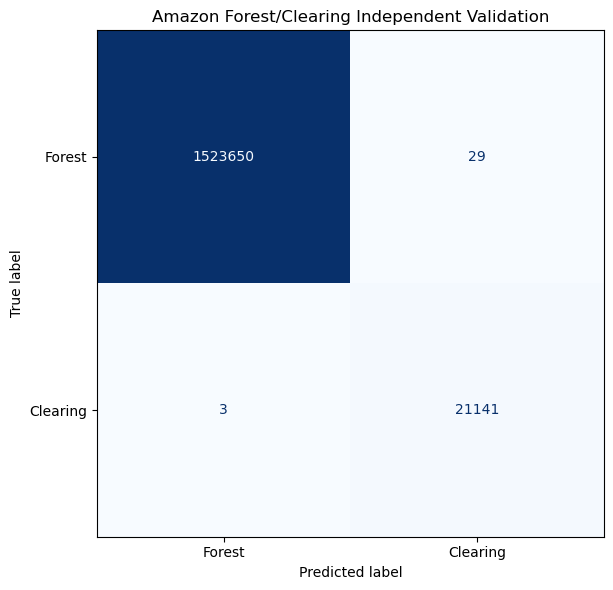

Overall accuracy: 0.999979

Confusion matrix:


,Predicted_Forest,Predicted_Clearing
Actual_Forest,1523650,29
Actual_Clearing,3,21141


Confusion matrix CSV: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_confusion_matrix.csv
Confusion matrix PNG: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_confusion_matrix.png


In [18]:
log.info("Independent model-performance evaluation started")

y_prediction = model.predict(X_validation)

overall_accuracy = accuracy_score(
    y_validation,
    y_prediction,
)

matrix = confusion_matrix(
    y_true=y_validation,
    y_pred=y_prediction,
    labels=class_values,
)

confusion_matrix_table = pd.DataFrame(
    matrix,
    index=[
        f"Actual_{class_names[value]}"
        for value in class_values
    ],
    columns=[
        f"Predicted_{class_names[value]}"
        for value in class_values
    ],
)

confusion_matrix_table.to_csv(
    confusion_matrix_csv_path
)

figure, axis = plt.subplots(
    figsize=(7, 6)
)

display_object = ConfusionMatrixDisplay(
    confusion_matrix=matrix,
    display_labels=target_names,
)

display_object.plot(
    ax=axis,
    cmap="Blues",
    values_format="d",
    colorbar=False,
)

axis.set_title(
    "Amazon Forest/Clearing Independent Validation"
)

figure.tight_layout()

figure.savefig(
    confusion_matrix_png_path,
    dpi=200,
    bbox_inches="tight",
)

plt.show()

print("Overall accuracy:", round(overall_accuracy, 6))
print("\nConfusion matrix:")
display(confusion_matrix_table)

print(
    "Confusion matrix CSV:",
    confusion_matrix_csv_path,
)

print(
    "Confusion matrix PNG:",
    confusion_matrix_png_path,
)

In [19]:
report_text = classification_report(
    y_true=y_validation,
    y_pred=y_prediction,
    labels=class_values,
    target_names=target_names,
    digits=6,
    zero_division=0,
)

report_dictionary = classification_report(
    y_true=y_validation,
    y_pred=y_prediction,
    labels=class_values,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

with open(
    classification_report_txt_path,
    "w",
    encoding="utf-8",
) as report_file:
    report_file.write(report_text)

class_metrics_table = pd.DataFrame(
    {
        class_name: report_dictionary[class_name]
        for class_name in target_names
    }
).transpose()

class_metrics_table.index.name = "class_name"

class_metrics_table.to_csv(
    class_metrics_csv_path
)

metadata = {
    "project": "Amazon BR163 PyEO",
    "model_name": model_name,
    "model_path": str(model_path),
    "training_raster": str(training_raster_path),
    "training_geopackage": str(training_gpkg_path),
    "training_layer": training_layer_name,
    "validation_layer": validation_layer_name,
    "band_order": band_order,
    "class_definitions": {
        str(key): value
        for key, value in class_names.items()
    },
    "estimator": "sklearn.ensemble.ExtraTreesClassifier",
    "estimator_settings": estimator_settings,
    "training_feature_rows": int(X_train.shape[0]),
    "validation_feature_rows": int(
        X_validation.shape[0]
    ),
    "overall_accuracy": float(overall_accuracy),
    "class_metrics": {
        class_name: {
            metric_name: float(metric_value)
            for metric_name, metric_value
            in report_dictionary[class_name].items()
        }
        for class_name in target_names
    },
    "confusion_matrix": matrix.tolist(),
    "outputs": {
        "model": str(model_path),
        "confusion_matrix_csv": str(
            confusion_matrix_csv_path
        ),
        "confusion_matrix_png": str(
            confusion_matrix_png_path
        ),
        "class_metrics_csv": str(
            class_metrics_csv_path
        ),
        "classification_report_txt": str(
            classification_report_txt_path
        ),
    },
    "limitations": [
        "Binary pilot model distinguishes Forest and Clearing only.",
        "Performance applies to the documented composite, band order, landscape, and validation sample.",
        "Independent validation polygons were digitized separately from training polygons.",
        "Remaining cloud, haze, seasonal differences, mixed pixels, and spectral variation may reduce transferability.",
    ],
}

with open(
    metadata_json_path,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        metadata,
        metadata_file,
        indent=2,
    )

print(report_text)

print("Overall accuracy:", round(overall_accuracy, 6))

print("\nPer-class metrics:")
display(
    class_metrics_table[
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ]
)

print("Classification report:", classification_report_txt_path)
print("Class metrics CSV:", class_metrics_csv_path)
print("Model metadata:", metadata_json_path)

log.info(
    "Independent overall accuracy: %.6f",
    overall_accuracy,
)

              precision    recall  f1-score   support

      Forest   0.999998  0.999981  0.999989   1523679
    Clearing   0.998630  0.999858  0.999244     21144

    accuracy                       0.999979   1544823
   macro avg   0.999314  0.999920  0.999617   1544823
weighted avg   0.999979  0.999979  0.999979   1544823

Overall accuracy: 0.999979

Per-class metrics:


,precision,recall,f1-score,support
class_name,,,,
Forest,0.999998,0.999981,0.999989,1523679.0
Clearing,0.998630,0.999858,0.999244,21144.0


2026-07-27 22:25:06,327: INFO: Independent overall accuracy: 0.999979


Classification report: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_classification_report.txt
Class metrics CSV: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_class_metrics.csv
Model metadata: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_metadata.json


In [21]:
# Balanced-pixel sensitivity evaluation
#
# This does not replace the independent validation result above.
# It tests whether the model remains strong when both classes contribute
# the same number of validation pixels.

balanced_rng = np.random.default_rng(101)

forest_indices = np.flatnonzero(y_validation == 1)
clearing_indices = np.flatnonzero(y_validation == 2)

balanced_pixels_per_class = min(
    len(forest_indices),
    len(clearing_indices),
)

balanced_forest_indices = balanced_rng.choice(
    forest_indices,
    size=balanced_pixels_per_class,
    replace=False,
)

balanced_clearing_indices = balanced_rng.choice(
    clearing_indices,
    size=balanced_pixels_per_class,
    replace=False,
)

balanced_indices = np.concatenate(
    [
        balanced_forest_indices,
        balanced_clearing_indices,
    ]
)

balanced_rng.shuffle(balanced_indices)

X_validation_balanced = X_validation[balanced_indices]
y_validation_balanced = y_validation[balanced_indices]

y_prediction_balanced = model.predict(
    X_validation_balanced
)

balanced_accuracy = accuracy_score(
    y_validation_balanced,
    y_prediction_balanced,
)

balanced_matrix = confusion_matrix(
    y_true=y_validation_balanced,
    y_pred=y_prediction_balanced,
    labels=class_values,
)

balanced_report_text = classification_report(
    y_true=y_validation_balanced,
    y_pred=y_prediction_balanced,
    labels=class_values,
    target_names=target_names,
    digits=6,
    zero_division=0,
)

balanced_report_dictionary = classification_report(
    y_true=y_validation_balanced,
    y_pred=y_prediction_balanced,
    labels=class_values,
    target_names=target_names,
    output_dict=True,
    zero_division=0,
)

balanced_metrics_table = pd.DataFrame(
    {
        class_name: balanced_report_dictionary[class_name]
        for class_name in target_names
    }
).transpose()

balanced_metrics_table.index.name = "class_name"

balanced_metrics_csv_path = (
    model_dir
    / f"{model_name}_balanced_validation_metrics.csv"
)

balanced_report_txt_path = (
    model_dir
    / f"{model_name}_balanced_validation_report.txt"
)

balanced_confusion_csv_path = (
    model_dir
    / f"{model_name}_balanced_validation_confusion_matrix.csv"
)

balanced_metrics_table.to_csv(
    balanced_metrics_csv_path
)

pd.DataFrame(
    balanced_matrix,
    index=[
        f"Actual_{class_names[value]}"
        for value in class_values
    ],
    columns=[
        f"Predicted_{class_names[value]}"
        for value in class_values
    ],
).to_csv(
    balanced_confusion_csv_path
)

with open(
    balanced_report_txt_path,
    "w",
    encoding="utf-8",
) as balanced_report_file:
    balanced_report_file.write(
        balanced_report_text
    )

print(
    "Balanced validation pixels per class:",
    balanced_pixels_per_class,
)

print(
    "Balanced overall accuracy:",
    round(balanced_accuracy, 6),
)

print("\nBalanced validation report:")
print(balanced_report_text)

print("Balanced per-class metrics:")
display(
    balanced_metrics_table[
        [
            "precision",
            "recall",
            "f1-score",
            "support",
        ]
    ]
)

print(
    "Balanced metrics CSV:",
    balanced_metrics_csv_path,
)

print(
    "Balanced report:",
    balanced_report_txt_path,
)

print(
    "Balanced confusion matrix:",
    balanced_confusion_csv_path,
)

Balanced validation pixels per class: 21144
Balanced overall accuracy: 0.999905

Balanced validation report:
              precision    recall  f1-score   support

      Forest   0.999858  0.999953  0.999905     21144
    Clearing   0.999953  0.999858  0.999905     21144

    accuracy                       0.999905     42288
   macro avg   0.999905  0.999905  0.999905     42288
weighted avg   0.999905  0.999905  0.999905     42288

Balanced per-class metrics:


,precision,recall,f1-score,support
class_name,,,,
Forest,0.999858,0.999953,0.999905,21144.0
Clearing,0.999953,0.999858,0.999905,21144.0


Balanced metrics CSV: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_balanced_validation_metrics.csv
Balanced report: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_balanced_validation_report.txt
Balanced confusion matrix: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_balanced_validation_confusion_matrix.csv


In [22]:
# Prepare classification and reporting output directories

outputs_dir = project_dir / "06_outputs"
reports_dir = project_dir / "12_reports"

outputs_dir.mkdir(parents=True, exist_ok=True)
reports_dir.mkdir(parents=True, exist_ok=True)

class_out_path = (
    outputs_dir
    / "composite_T21MYM_20240912T140049_full_class.tif"
)

classification_summary_path = (
    reports_dir
    / "classification_summary.txt"
)

class_area_statistics_path = (
    reports_dir
    / "class_area_statistics.csv"
)

print("Classification output directory:", outputs_dir)
print("Reports directory:", reports_dir)
print("Classified raster output:", class_out_path)
print("Classification summary:", classification_summary_path)
print("Class area statistics:", class_area_statistics_path)

Classification output directory: C:\GIS\projects\Amazon_BR163_PyEO\06_outputs
Reports directory: C:\GIS\projects\Amazon_BR163_PyEO\12_reports
Classified raster output: C:\GIS\projects\Amazon_BR163_PyEO\06_outputs\composite_T21MYM_20240912T140049_full_class.tif
Classification summary: C:\GIS\projects\Amazon_BR163_PyEO\12_reports\classification_summary.txt
Class area statistics: C:\GIS\projects\Amazon_BR163_PyEO\12_reports\class_area_statistics.csv


In a classification, the precision for a class is the number of true positives (i.e. the number of pixels correctly labelled as belonging to the class) divided by the total number of pixels labelled as belonging to the class (i.e. the sum of true positives and false positives). 

Recall for a class is defined as the number of true positives (i.e. correctly classified pixels) divided by the total number of pixels that actually belong to the class (i.e. the sum of true positives and false negatives, which are pixels which were not labelled as belonging to the class but should have been). 

The F1 score is the harmonic mean of the precision and recall and indicates the overall accuracy of each class. 

Support is the number of pixels that belongs to each class in the training data.

(Modified after Wikipedia, 2024).

## Image Classification

- Once we are happy with the performance of the model we can now classify a Sentinel-2 image tiles so long as they have similar land use and vegetation cover (and thus spectral characteristics) to the imagery used to train the model.
- Here, we will simply use our training image and see how well the classification extends over the untrained areas of the image

In [20]:
pwd

'C:\\GIS\\src\\pyeo'

- Note: your model folder should now contain a classified image with '_full_class' appended to the raw image name - check using the File Explorer.

In [23]:
log.info("Amazon baseline-composite classification started")

test_raster_path = training_raster_path

if not test_raster_path.is_file():
    raise FileNotFoundError(
        f"Classification raster does not exist: "
        f"{test_raster_path}"
    )

if not model_path.is_file():
    raise FileNotFoundError(
        f"Trained model does not exist: {model_path}"
    )

free_space_gb = (
    shutil.disk_usage(model_dir).free
    / (1024 ** 3)
)

print(
    "Free space before classification:",
    round(free_space_gb, 2),
    "GB",
)

if free_space_gb < 5.0:
    raise RuntimeError(
        "At least 5 GB free space is required before "
        "classifying the full Sentinel-2 tile."
    )

cls.classify_image(
    image_path=str(test_raster_path),
    model_path=str(model_path),
    class_out_path=str(class_out_path),
    prob_out_path=None,
    apply_mask=False,
    out_format="GTiff",
    chunks=10,
    nodata=0,
    skip_existing=False,
)

assert class_out_path.is_file(), (
    f"Classified raster not created: {class_out_path}"
)

log.info(
    "Classification image saved: %s",
    class_out_path,
)

print("CLASSIFICATION: COMPLETE")
print("Classified raster:", class_out_path)

2026-07-27 23:05:04,340: INFO: Amazon baseline-composite classification started
2026-07-27 23:05:04,349: INFO: Classifying file: C:\GIS\data\Amazon_BR163_PyEO\tile_data\21MYM\composite\composite_T21MYM_20240912T140049.tif
2026-07-27 23:05:04,350: INFO: Saved model     : C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees.pkl


Free space before classification: 20.12 GB


2026-07-27 23:05:16,982: INFO: Proportion of non-missing values: 99.99%
2026-07-27 23:05:20,507: INFO:    Number of chunks 10 Chunk size 12054830 Chunk residual 1
2026-07-27 23:05:20,542: INFO:    Classifying chunk 1 of size 12054830
2026-07-27 23:05:44,087: INFO:    Classifying chunk 2 of size 12054830
2026-07-27 23:06:06,298: INFO:    Classifying chunk 3 of size 12054830
2026-07-27 23:06:27,959: INFO:    Classifying chunk 4 of size 12054830
2026-07-27 23:06:49,594: INFO:    Classifying chunk 5 of size 12054830
2026-07-27 23:07:12,955: INFO:    Classifying chunk 6 of size 12054830
2026-07-27 23:07:40,245: INFO:    Classifying chunk 7 of size 12054830
2026-07-27 23:08:07,183: INFO:    Classifying chunk 8 of size 12054830
2026-07-27 23:08:28,824: INFO:    Classifying chunk 9 of size 12054830
2026-07-27 23:08:53,505: INFO:    Classifying chunk 10 of size 12054831
2026-07-27 23:09:54,175: INFO: Created classification image file: C:\GIS\projects\Amazon_BR163_PyEO\06_outputs\composite_T21MY

CLASSIFICATION: COMPLETE
Classified raster: C:\GIS\projects\Amazon_BR163_PyEO\06_outputs\composite_T21MYM_20240912T140049_full_class.tif


## Visualise the Classification Imagery

Now we can now define a function to colormap and visualise the classification image

In [24]:
def visualise_amazon_classification(
    classified_path: Path,
) -> pd.DataFrame:
    dataset = gdal.Open(str(classified_path))

    if dataset is None:
        raise RuntimeError(
            f"Could not open classified raster: "
            f"{classified_path}"
        )

    band = dataset.GetRasterBand(1)

    full_array = band.ReadAsArray()

    unique_values, pixel_counts = np.unique(
        full_array,
        return_counts=True,
    )

    distribution_table = pd.DataFrame(
        {
            "class_value": unique_values.astype(int),
            "pixel_count": pixel_counts.astype(int),
        }
    )

    distribution_table["class_name"] = (
        distribution_table["class_value"]
        .map(
            {
                0: "NoData",
                1: "Forest",
                2: "Clearing",
            }
        )
        .fillna("Unexpected class")
    )

    valid_pixel_total = int(
        distribution_table.loc[
            distribution_table["class_value"] != 0,
            "pixel_count",
        ].sum()
    )

    distribution_table["percent_valid_pixels"] = 0.0

    if valid_pixel_total > 0:
        valid_mask = (
            distribution_table["class_value"] != 0
        )

        distribution_table.loc[
            valid_mask,
            "percent_valid_pixels",
        ] = (
            distribution_table.loc[
                valid_mask,
                "pixel_count",
            ]
            / valid_pixel_total
            * 100.0
        )

    display_array = band.ReadAsArray(
        buf_xsize=1098,
        buf_ysize=1098,
    )

    colour_map = ListedColormap(
        [
            "black",
            "darkgreen",
            "tan",
        ]
    )

    normalizer = BoundaryNorm(
        [-0.5, 0.5, 1.5, 2.5],
        colour_map.N,
    )

    figure, axis = plt.subplots(
        figsize=(10, 10)
    )

    image = axis.imshow(
        display_array,
        cmap=colour_map,
        norm=normalizer,
    )

    axis.set_title(
        "Amazon BR163 Forest/Clearing Classification"
    )

    axis.set_axis_off()

    colorbar = figure.colorbar(
        image,
        ax=axis,
        ticks=[0, 1, 2],
        fraction=0.046,
        pad=0.04,
    )

    colorbar.ax.set_yticklabels(
        [
            "NoData",
            "Forest",
            "Clearing",
        ]
    )

    figure.tight_layout()
    plt.show()

    dataset = None

    return distribution_table

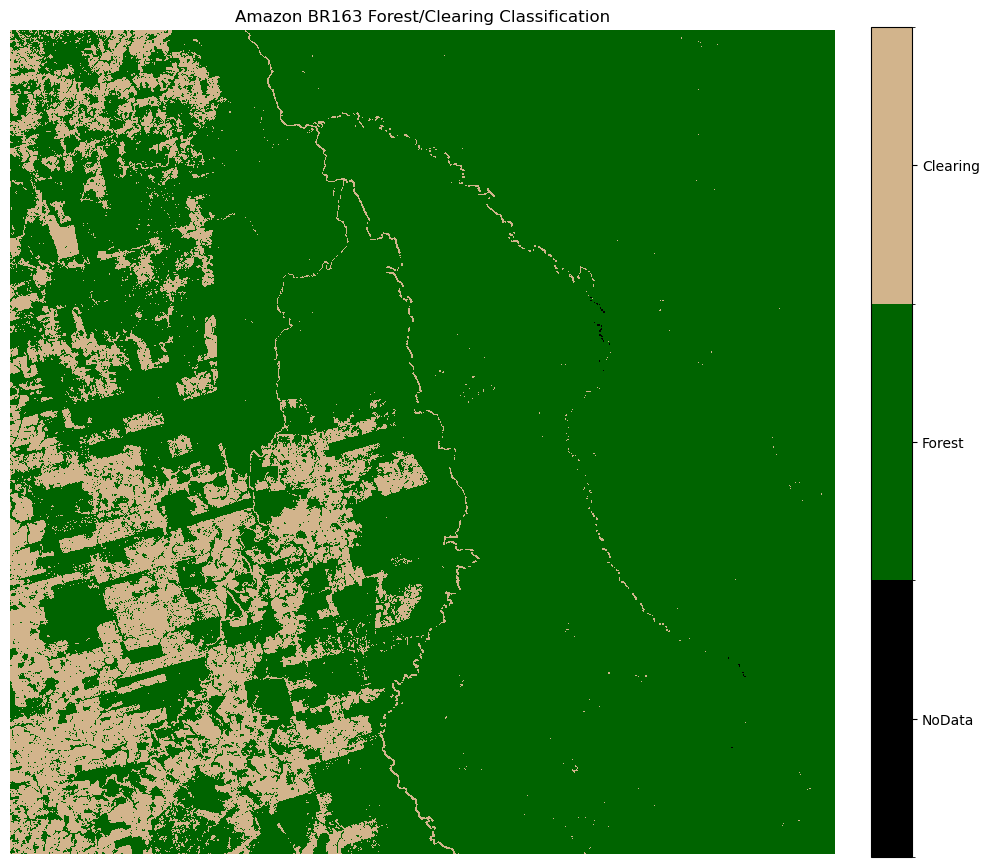

Classified raster distribution:


,class_value,pixel_count,class_name,percent_valid_pixels
0,0,12099,NoData,0.00000
1,1,101374889,Forest,84.09483
2,2,19173412,Clearing,15.90517


CLASSIFIED RASTER CLASS QA: PASS


In [25]:
classified_distribution = (
    visualise_amazon_classification(
        class_out_path
    )
)

print("Classified raster distribution:")
display(classified_distribution)

unexpected_classes = set(
    classified_distribution["class_value"]
) - {0, 1, 2}

assert not unexpected_classes, (
    f"Unexpected raster classes detected: "
    f"{unexpected_classes}"
)

print("CLASSIFIED RASTER CLASS QA: PASS")

In [1]:
# Restore the minimum notebook state after a kernel restart.
# This cell does not retrain the model or rerun classification.

import json
import logging
from pathlib import Path

import pandas as pd
from osgeo import gdal
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
)

project_dir = Path(
    r"C:\GIS\projects\Amazon_BR163_PyEO"
)

training_raster_path = Path(
    r"C:\GIS\data\Amazon_BR163_PyEO"
    r"\tile_data\21MYM\composite"
    r"\composite_T21MYM_20240912T140049.tif"
)

training_gpkg_path = (
    project_dir
    / "04_training"
    / "amazon_training.gpkg"
)

training_layer_name = "training_polygons"
validation_layer_name = "validation_polygons"

model_dir = project_dir / "05_model"
outputs_dir = project_dir / "06_outputs"
log_dir = project_dir / "11_logs"
reports_dir = project_dir / "12_reports"

model_path = (
    model_dir
    / "amazon_forest_clearing_extratrees.pkl"
)

metadata_json_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_metadata.json"
)

class_metrics_csv_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_class_metrics.csv"
)

confusion_csv_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_confusion_matrix.csv"
)

balanced_metrics_csv_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_balanced_validation_metrics.csv"
)

balanced_report_txt_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_balanced_validation_report.txt"
)

balanced_confusion_csv_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_balanced_validation_confusion_matrix.csv"
)

class_out_path = (
    outputs_dir
    / "composite_T21MYM_20240912T140049_full_class.tif"
)

classification_summary_path = (
    reports_dir
    / "classification_summary.txt"
)

class_area_statistics_path = (
    reports_dir
    / "class_area_statistics.csv"
)

log_path = (
    log_dir
    / "amazon_model_training.log"
)

band_order = [
    "B02_blue",
    "B03_green",
    "B04_red",
    "B08_nir",
]

class_names = {
    1: "Forest",
    2: "Clearing",
}

target_names = [
    "Forest",
    "Clearing",
]

estimator_settings = {
    "bootstrap": False,
    "criterion": "gini",
    "max_features": 0.55,
    "min_samples_leaf": 2,
    "min_samples_split": 16,
    "n_estimators": 100,
    "n_jobs": -1,
    "class_weight": "balanced",
    "random_state": 101,
}

required_paths = [
    training_raster_path,
    model_path,
    metadata_json_path,
    class_metrics_csv_path,
    confusion_csv_path,
    class_out_path,
]

for required_path in required_paths:
    if not required_path.is_file():
        raise FileNotFoundError(
            f"Required file is missing: {required_path}"
        )

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)

log_dir.mkdir(
    parents=True,
    exist_ok=True,
)

log = logging.getLogger(
    "amazon_model_training_recovery"
)

if not log.handlers:
    log.setLevel(logging.INFO)

    file_handler = logging.FileHandler(
        log_path,
        encoding="utf-8",
    )

    file_handler.setFormatter(
        logging.Formatter(
            "%(asctime)s | %(levelname)s | %(message)s"
        )
    )

    log.addHandler(file_handler)

print("RECOVERY STATE: PASS")
print("Classified raster:", class_out_path)
print("Model metadata:", metadata_json_path)
print("Reports directory:", reports_dir)

RECOVERY STATE: PASS
Classified raster: C:\GIS\projects\Amazon_BR163_PyEO\06_outputs\composite_T21MYM_20240912T140049_full_class.tif
Model metadata: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_metadata.json
Reports directory: C:\GIS\projects\Amazon_BR163_PyEO\12_reports


In [4]:
# ============================================================
# POST-KERNEL CLASSIFICATION REPORTING AND STRUCTURAL QA
#
# This cell reads completed outputs from disk.
# It does not retrain the model.
# It does not rerun full-raster classification.
# ============================================================

import json
import logging
from datetime import datetime, timezone
from pathlib import Path

import pandas as pd
from osgeo import gdal, osr


# ------------------------------------------------------------
# 1. Restore all required paths
# ------------------------------------------------------------

project_dir = Path(
    r"C:\GIS\projects\Amazon_BR163_PyEO"
)

training_raster_path = Path(
    r"C:\GIS\data\Amazon_BR163_PyEO"
    r"\tile_data\21MYM\composite"
    r"\composite_T21MYM_20240912T140049.tif"
)

training_gpkg_path = (
    project_dir
    / "04_training"
    / "amazon_training.gpkg"
)

model_dir = project_dir / "05_model"
outputs_dir = project_dir / "06_outputs"
log_dir = project_dir / "11_logs"
reports_dir = project_dir / "12_reports"

model_path = (
    model_dir
    / "amazon_forest_clearing_extratrees.pkl"
)

metadata_json_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_metadata.json"
)

class_metrics_csv_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_class_metrics.csv"
)

confusion_matrix_csv_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_confusion_matrix.csv"
)

confusion_matrix_png_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_confusion_matrix.png"
)

balanced_metrics_csv_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_balanced_validation_metrics.csv"
)

balanced_confusion_csv_path = (
    model_dir
    / "amazon_forest_clearing_extratrees_balanced_validation_confusion_matrix.csv"
)

class_out_path = (
    outputs_dir
    / "composite_T21MYM_20240912T140049_full_class.tif"
)

log_path = (
    log_dir
    / "amazon_model_training.log"
)

classification_summary_path = (
    reports_dir
    / "classification_summary.txt"
)

class_area_statistics_path = (
    reports_dir
    / "class_area_statistics.csv"
)

reports_dir.mkdir(
    parents=True,
    exist_ok=True,
)

log_dir.mkdir(
    parents=True,
    exist_ok=True,
)


# ------------------------------------------------------------
# 2. Confirm required completed outputs
# ------------------------------------------------------------

required_files = [
    training_raster_path,
    training_gpkg_path,
    model_path,
    metadata_json_path,
    class_metrics_csv_path,
    confusion_matrix_csv_path,
    confusion_matrix_png_path,
    class_out_path,
]

for required_file in required_files:
    if not required_file.is_file():
        raise FileNotFoundError(
            f"Required file is missing: {required_file}"
        )

print("REQUIRED COMPLETED OUTPUTS: PASS")


# ------------------------------------------------------------
# 3. Configure logging
# ------------------------------------------------------------

log = logging.getLogger(
    "amazon_post_kernel_reporting"
)

log.setLevel(logging.INFO)
log.propagate = False

if not log.handlers:
    file_handler = logging.FileHandler(
        log_path,
        encoding="utf-8",
    )

    file_handler.setFormatter(
        logging.Formatter(
            "%(asctime)s | %(levelname)s | %(message)s"
        )
    )

    log.addHandler(file_handler)

log.info(
    "Post-kernel classification reporting started"
)


# ------------------------------------------------------------
# 4. Formally assign class value 0 as NoData
# ------------------------------------------------------------

update_dataset = gdal.Open(
    str(class_out_path),
    gdal.GA_Update,
)

if update_dataset is None:
    raise RuntimeError(
        "Could not open the classified raster for update: "
        f"{class_out_path}"
    )

update_band = update_dataset.GetRasterBand(1)

if update_band is None:
    raise RuntimeError(
        "Could not access band 1 of the classified raster"
    )

if update_band.GetNoDataValue() != 0:
    update_band.SetNoDataValue(0)
    update_band.FlushCache()
    update_dataset.FlushCache()

update_band = None
update_dataset = None

print("NODATA METADATA ALIGNMENT: PASS")


# ------------------------------------------------------------
# 5. Open rasters for structural QA
# ------------------------------------------------------------

input_dataset = gdal.Open(
    str(training_raster_path),
    gdal.GA_ReadOnly,
)

classified_dataset = gdal.Open(
    str(class_out_path),
    gdal.GA_ReadOnly,
)

if input_dataset is None:
    raise RuntimeError(
        f"Could not open input composite: "
        f"{training_raster_path}"
    )

if classified_dataset is None:
    raise RuntimeError(
        f"Could not open classified raster: "
        f"{class_out_path}"
    )

classified_band = classified_dataset.GetRasterBand(1)

classified_width = classified_dataset.RasterXSize
classified_height = classified_dataset.RasterYSize
classified_band_count = classified_dataset.RasterCount
classified_geotransform = classified_dataset.GetGeoTransform()
classified_projection = classified_dataset.GetProjection()

input_width = input_dataset.RasterXSize
input_height = input_dataset.RasterYSize
input_geotransform = input_dataset.GetGeoTransform()
input_projection = input_dataset.GetProjection()

classified_spatial_reference = osr.SpatialReference()
classified_spatial_reference.ImportFromWkt(
    classified_projection
)

classified_epsg = (
    classified_spatial_reference.GetAuthorityCode(None)
)

pixel_width_metres = abs(
    classified_geotransform[1]
)

pixel_height_metres = abs(
    classified_geotransform[5]
)

pixel_area_m2 = (
    pixel_width_metres
    * pixel_height_metres
)


# ------------------------------------------------------------
# 6. Structural QA assertions
# ------------------------------------------------------------

assert classified_width == 10980, (
    f"Expected width 10980, found {classified_width}"
)

assert classified_height == 10980, (
    f"Expected height 10980, found {classified_height}"
)

assert classified_band_count == 1, (
    f"Expected one band, found {classified_band_count}"
)

assert classified_width == input_width, (
    "Classified raster width differs from input composite"
)

assert classified_height == input_height, (
    "Classified raster height differs from input composite"
)

assert classified_geotransform == input_geotransform, (
    "Classified raster geotransform differs from input"
)

assert classified_projection == input_projection, (
    "Classified raster CRS differs from input composite"
)

assert classified_epsg == "32721", (
    f"Expected EPSG:32721, found EPSG:{classified_epsg}"
)

assert abs(pixel_width_metres - 10.0) < 1e-9, (
    f"Expected 10 m pixel width, found "
    f"{pixel_width_metres}"
)

assert abs(pixel_height_metres - 10.0) < 1e-9, (
    f"Expected 10 m pixel height, found "
    f"{pixel_height_metres}"
)

assert classified_band.DataType == gdal.GDT_Byte, (
    "Classified raster is not Byte data type"
)

assert classified_band.GetNoDataValue() == 0, (
    "Classified raster NoData value is not 0"
)

print("CLASSIFIED RASTER STRUCTURAL QA: PASS")


# ------------------------------------------------------------
# 7. Calculate exact class counts using GDAL histogram
#
# This avoids loading the full 10980 x 10980 raster into RAM.
# ------------------------------------------------------------

histogram = classified_band.GetHistogram(
    min=-0.5,
    max=255.5,
    buckets=256,
    include_out_of_range=0,
    approx_ok=0,
)

if histogram is None:
    raise RuntimeError(
        "GDAL could not calculate the classified-raster "
        "histogram"
    )

# Because class value 0 is formally assigned as NoData,
# GDAL excludes those pixels from GetHistogram().
# Forest and Clearing are counted from the histogram,
# while NoData is derived from the total raster size.

forest_pixels = int(histogram[1])
clearing_pixels = int(histogram[2])

unexpected_pixels = int(
    sum(histogram[3:])
)

assert unexpected_pixels == 0, (
    f"Unexpected classified pixels detected: "
    f"{unexpected_pixels}"
)

total_pixels = (
    classified_width
    * classified_height
)

valid_pixels = (
    forest_pixels
    + clearing_pixels
)

nodata_pixels = (
    total_pixels
    - valid_pixels
)

assert nodata_pixels >= 0, (
    f"Derived NoData count is negative: "
    f"{nodata_pixels:,}"
)

counted_pixels = (
    nodata_pixels
    + forest_pixels
    + clearing_pixels
)

assert counted_pixels == total_pixels, (
    f"Derived class counts total {counted_pixels:,} pixels, "
    f"but raster contains {total_pixels:,}"
)

assert nodata_pixels == 12_099, (
    f"Expected 12,099 NoData pixels, "
    f"but found {nodata_pixels:,}"
)

print(
    "NoData pixels derived from raster total:",
    f"{nodata_pixels:,}",
)

assert valid_pixels > 0, (
    "No valid Forest or Clearing pixels were found"
)

forest_percent_valid = (
    forest_pixels
    / valid_pixels
    * 100.0
)

clearing_percent_valid = (
    clearing_pixels
    / valid_pixels
    * 100.0
)

print("CLASS VALUE QA: PASS")


# ------------------------------------------------------------
# 8. Create and save class-area statistics
# ------------------------------------------------------------

area_statistics = pd.DataFrame(
    [
        {
            "class_value": 0,
            "class_name": "NoData",
            "pixel_count": nodata_pixels,
            "percent_valid_pixels": 0.0,
        },
        {
            "class_value": 1,
            "class_name": "Forest",
            "pixel_count": forest_pixels,
            "percent_valid_pixels": forest_percent_valid,
        },
        {
            "class_value": 2,
            "class_name": "Clearing",
            "pixel_count": clearing_pixels,
            "percent_valid_pixels": clearing_percent_valid,
        },
    ]
)

area_statistics["area_m2"] = (
    area_statistics["pixel_count"]
    * pixel_area_m2
)

area_statistics["area_hectares"] = (
    area_statistics["area_m2"]
    / 10_000.0
)

area_statistics["area_km2"] = (
    area_statistics["area_m2"]
    / 1_000_000.0
)

area_statistics.to_csv(
    class_area_statistics_path,
    index=False,
)

print("CLASS AREA STATISTICS: SAVED")
display(area_statistics)


# ------------------------------------------------------------
# 9. Read saved validation evidence from disk
# ------------------------------------------------------------

with open(
    metadata_json_path,
    "r",
    encoding="utf-8",
) as metadata_file:
    metadata = json.load(metadata_file)

class_metrics = pd.read_csv(
    class_metrics_csv_path
)

confusion_matrix_table = pd.read_csv(
    confusion_matrix_csv_path,
    index_col=0,
)

balanced_metrics = None

if balanced_metrics_csv_path.is_file():
    balanced_metrics = pd.read_csv(
        balanced_metrics_csv_path
    )

balanced_confusion = None

if balanced_confusion_csv_path.is_file():
    balanced_confusion = pd.read_csv(
        balanced_confusion_csv_path,
        index_col=0,
    )


# ------------------------------------------------------------
# 10. Preserve publication limitations
# ------------------------------------------------------------

publication_limitations = [
    (
        "The model is a binary pilot classifier that "
        "distinguishes Forest and Clearing only."
    ),
    (
        "Training and validation polygons were created within "
        "the same pilot landscape, although validation polygons "
        "were spatially separate from training polygons."
    ),
    (
        "Validation support values count sampled pixels rather "
        "than fully independent observations. Pixels within the "
        "same polygon are spatially autocorrelated."
    ),
    (
        "The very high validation scores demonstrate strong "
        "spectral separation within the sampled pilot landscape. "
        "They do not establish equivalent performance throughout "
        "the wider Amazon."
    ),
    (
        "Model transferability may be reduced by differences in "
        "forest structure, disturbance type, seasonality, "
        "atmospheric conditions, illumination, soil exposure, "
        "mixed pixels, acquisition date, and preprocessing."
    ),
    (
        "The balanced-pixel sensitivity assessment reduces the "
        "influence of unequal class pixel counts, but does not "
        "remove within-polygon spatial autocorrelation."
    ),
    (
        "The resulting class-area statistics are model-derived "
        "outputs and must not be presented as independently "
        "verified official forest-area estimates."
    ),
]


# ------------------------------------------------------------
# 11. Update model metadata
# ------------------------------------------------------------

metadata["classification"] = {
    "input_raster": str(training_raster_path),
    "classified_raster": str(class_out_path),
    "width": int(classified_width),
    "height": int(classified_height),
    "band_count": int(classified_band_count),
    "data_type": "Byte",
    "epsg": classified_epsg,
    "pixel_size_metres": [
        float(pixel_width_metres),
        float(pixel_height_metres),
    ],
    "nodata_value": 0,
    "compression": "LZW",
    "class_definitions": {
        "0": "NoData",
        "1": "Forest",
        "2": "Clearing",
    },
    "class_distribution": (
        area_statistics.to_dict(
            orient="records"
        )
    ),
}

metadata["limitations"] = publication_limitations

metadata.setdefault(
    "outputs",
    {}
)

metadata["outputs"].update(
    {
        "classified_raster": str(
            class_out_path
        ),
        "classification_summary": str(
            classification_summary_path
        ),
        "class_area_statistics": str(
            class_area_statistics_path
        ),
        "training_log": str(
            log_path
        ),
    }
)

with open(
    metadata_json_path,
    "w",
    encoding="utf-8",
) as metadata_file:
    json.dump(
        metadata,
        metadata_file,
        indent=2,
    )

print("MODEL METADATA ALIGNMENT: PASS")


# ------------------------------------------------------------
# 12. Prepare readable validation text
# ------------------------------------------------------------

overall_accuracy = metadata.get(
    "validation",
    {}
).get(
    "overall_accuracy"
)

balanced_validation = metadata.get(
    "balanced_validation",
    {}
)

balanced_accuracy = balanced_validation.get(
    "overall_accuracy"
)

forest_row = area_statistics.loc[
    area_statistics["class_value"] == 1
].iloc[0]

clearing_row = area_statistics.loc[
    area_statistics["class_value"] == 2
].iloc[0]

nodata_row = area_statistics.loc[
    area_statistics["class_value"] == 0
].iloc[0]


# ------------------------------------------------------------
# 13. Write classification summary
# ------------------------------------------------------------

summary_lines = [
    "AMAZON BR163 FOREST/CLEARING CLASSIFICATION SUMMARY",
    "=" * 62,
    "",
    (
        "Generated UTC: "
        f"{datetime.now(timezone.utc).isoformat()}"
    ),
    "",
    "INPUTS AND MODEL",
    "-" * 30,
    f"Input composite: {training_raster_path}",
    f"Training GeoPackage: {training_gpkg_path}",
    f"Trained model: {model_path}",
    (
        "Input band order: B02 Blue, B03 Green, "
        "B04 Red, B08 Near Infrared"
    ),
    "Class 1: Forest",
    "Class 2: Clearing",
    "",
    "VALIDATION EVIDENCE",
    "-" * 30,
    (
        f"Overall accuracy: {overall_accuracy}"
        if overall_accuracy is not None
        else "Overall accuracy: recorded in model metadata"
    ),
    (
        f"Balanced overall accuracy: {balanced_accuracy}"
        if balanced_accuracy is not None
        else (
            "Balanced overall accuracy: see balanced "
            "validation output files"
        )
    ),
    (
        f"Class metrics file: "
        f"{class_metrics_csv_path}"
    ),
    (
        f"Confusion matrix file: "
        f"{confusion_matrix_csv_path}"
    ),
    "",
    "CLASSIFIED RASTER",
    "-" * 30,
    f"Output raster: {class_out_path}",
    (
        f"Dimensions: {classified_width} columns x "
        f"{classified_height} rows"
    ),
    f"Band count: {classified_band_count}",
    "Data type: Byte",
    f"CRS: EPSG:{classified_epsg}",
    (
        f"Pixel size: {pixel_width_metres:.1f} x "
        f"{pixel_height_metres:.1f} metres"
    ),
    "NoData value: 0",
    "Compression: LZW",
    "",
    "CLASS DISTRIBUTION",
    "-" * 30,
    (
        f"Forest: {forest_pixels:,} pixels; "
        f"{forest_percent_valid:.5f}% of valid pixels; "
        f"{forest_row['area_hectares']:,.2f} ha; "
        f"{forest_row['area_km2']:,.2f} km2"
    ),
    (
        f"Clearing: {clearing_pixels:,} pixels; "
        f"{clearing_percent_valid:.5f}% of valid pixels; "
        f"{clearing_row['area_hectares']:,.2f} ha; "
        f"{clearing_row['area_km2']:,.2f} km2"
    ),
    (
        f"NoData: {nodata_pixels:,} pixels; "
        f"{nodata_row['area_hectares']:,.2f} ha; "
        f"{nodata_row['area_km2']:,.2f} km2"
    ),
    "",
    "STRUCTURAL QA",
    "-" * 30,
    "Raster opened successfully: PASS",
    "Raster dimensions match the input composite: PASS",
    "Raster geotransform matches the input composite: PASS",
    "Raster CRS matches the input composite: PASS",
    "Raster CRS is EPSG:32721: PASS",
    "Raster pixel size is 10 x 10 metres: PASS",
    "Raster contains one Byte band: PASS",
    "Class value 0 is formally assigned as NoData: PASS",
    "Only class values 0, 1, and 2 are present: PASS",
    "",
    "LIMITATIONS AND INTERPRETATION",
    "-" * 30,
]

for limitation_number, limitation in enumerate(
    publication_limitations,
    start=1,
):
    summary_lines.append(
        f"{limitation_number}. {limitation}"
    )

summary_lines.extend(
    [
        "",
        "OUTPUT FILES",
        "-" * 30,
        f"Model: {model_path}",
        f"Model metadata: {metadata_json_path}",
        f"Class metrics: {class_metrics_csv_path}",
        (
            "Confusion matrix CSV: "
            f"{confusion_matrix_csv_path}"
        ),
        (
            "Confusion matrix PNG: "
            f"{confusion_matrix_png_path}"
        ),
        f"Classified raster: {class_out_path}",
        (
            "Class-area statistics: "
            f"{class_area_statistics_path}"
        ),
        (
            "Classification summary: "
            f"{classification_summary_path}"
        ),
        f"Processing log: {log_path}",
    ]
)

with open(
    classification_summary_path,
    "w",
    encoding="utf-8",
) as summary_file:
    summary_file.write(
        "\n".join(summary_lines)
    )


# ------------------------------------------------------------
# 14. Log completion and close datasets
# ------------------------------------------------------------

log.info(
    "Classified-raster structural QA passed"
)

log.info(
    "Class-area statistics saved: %s",
    class_area_statistics_path,
)

log.info(
    "Classification summary saved: %s",
    classification_summary_path,
)

log.info(
    "Model metadata aligned: %s",
    metadata_json_path,
)

classified_band = None
classified_dataset = None
input_dataset = None

print()
print("POST-KERNEL CLASSIFICATION REPORTING: COMPLETE")
print("CLASSIFIED RASTER STRUCTURAL QA: PASS")
print("CLASS VALUE QA: PASS")
print("MODEL METADATA ALIGNMENT: PASS")
print("Classification summary:", classification_summary_path)
print("Class area statistics:", class_area_statistics_path)
print("Updated metadata:", metadata_json_path)

REQUIRED COMPLETED OUTPUTS: PASS
NODATA METADATA ALIGNMENT: PASS
CLASSIFIED RASTER STRUCTURAL QA: PASS
NoData pixels derived from raster total: 12,099
CLASS VALUE QA: PASS
CLASS AREA STATISTICS: SAVED


,class_value,class_name,pixel_count,percent_valid_pixels,area_m2,area_hectares,area_km2
0,0,NoData,12099,0.00000,1.209900e+06,120.99,1.2099
1,1,Forest,101374889,84.09483,1.013749e+10,1013748.89,10137.4889
2,2,Clearing,19173412,15.90517,1.917341e+09,191734.12,1917.3412


MODEL METADATA ALIGNMENT: PASS

POST-KERNEL CLASSIFICATION REPORTING: COMPLETE
CLASSIFIED RASTER STRUCTURAL QA: PASS
CLASS VALUE QA: PASS
MODEL METADATA ALIGNMENT: PASS
Classification summary: C:\GIS\projects\Amazon_BR163_PyEO\12_reports\classification_summary.txt
Class area statistics: C:\GIS\projects\Amazon_BR163_PyEO\12_reports\class_area_statistics.csv
Updated metadata: C:\GIS\projects\Amazon_BR163_PyEO\05_model\amazon_forest_clearing_extratrees_metadata.json


In [5]:
# ============================================================
# FINAL MODEL-PHASE OUTPUT MANIFEST AND COMPLETION QA
# ============================================================

from pathlib import Path
import pandas as pd

expected_output_files = {
    "trained_model": (
        model_dir
        / "amazon_forest_clearing_extratrees.pkl"
    ),
    "model_metadata": (
        model_dir
        / "amazon_forest_clearing_extratrees_metadata.json"
    ),
    "class_metrics": (
        model_dir
        / "amazon_forest_clearing_extratrees_class_metrics.csv"
    ),
    "confusion_matrix_csv": (
        model_dir
        / "amazon_forest_clearing_extratrees_confusion_matrix.csv"
    ),
    "confusion_matrix_png": (
        model_dir
        / "amazon_forest_clearing_extratrees_confusion_matrix.png"
    ),
    "classified_raster": (
        outputs_dir
        / "composite_T21MYM_20240912T140049_full_class.tif"
    ),
    "training_log": (
        log_dir
        / "amazon_model_training.log"
    ),
    "classification_summary": (
        reports_dir
        / "classification_summary.txt"
    ),
    "class_area_statistics": (
        reports_dir
        / "class_area_statistics.csv"
    ),
}

manifest_records = []

for output_name, output_path in expected_output_files.items():

    exists = output_path.is_file()

    size_bytes = (
        output_path.stat().st_size
        if exists
        else 0
    )

    manifest_records.append(
        {
            "output_name": output_name,
            "exists": exists,
            "size_bytes": size_bytes,
            "path": str(output_path),
        }
    )

output_manifest = pd.DataFrame(
    manifest_records
)

display(output_manifest)

missing_outputs = output_manifest.loc[
    ~output_manifest["exists"],
    "output_name",
].tolist()

empty_outputs = output_manifest.loc[
    output_manifest["exists"]
    & (output_manifest["size_bytes"] == 0),
    "output_name",
].tolist()

assert not missing_outputs, (
    f"Missing required outputs: {missing_outputs}"
)

assert not empty_outputs, (
    f"Zero-byte required outputs: {empty_outputs}"
)

assert class_out_path.stat().st_size > 1_000_000, (
    "Classified raster appears unexpectedly small."
)

assert classification_summary_path.stat().st_size > 500, (
    "Classification summary appears incomplete."
)

assert class_area_statistics_path.stat().st_size > 100, (
    "Class-area statistics file appears incomplete."
)

print()
print("=" * 70)
print("FINAL MODEL-PHASE OUTPUT MANIFEST: PASS")
print("=" * 70)

print(f"Verified outputs: {len(output_manifest)}")

total_size_mb = (
    output_manifest["size_bytes"].sum()
    / (1024 ** 2)
)

print(
    f"Total output size: "
    f"{total_size_mb:.2f} MB"
)

print()
print("All required outputs exist.")
print("All required outputs are non-empty.")
print("Baseline model phase completed successfully.")
print()
print("Project is ready for:")
print("  ✓ Multi-date classification")
print("  ✓ Change detection")
print("  ✓ Accuracy assessment")
print("  ✓ Publication-quality reporting")
print("=" * 70)

,output_name,exists,size_bytes,path
0,trained_model,True,439129,C:\GIS\projects\Amazon_BR163_PyEO\05_model\ama...
1,model_metadata,True,5294,C:\GIS\projects\Amazon_BR163_PyEO\05_model\ama...
2,class_metrics,True,195,C:\GIS\projects\Amazon_BR163_PyEO\05_model\ama...
3,confusion_matrix_csv,True,89,C:\GIS\projects\Amazon_BR163_PyEO\05_model\ama...
4,confusion_matrix_png,True,47710,C:\GIS\projects\Amazon_BR163_PyEO\05_model\ama...
5,classified_raster,True,4275480,C:\GIS\projects\Amazon_BR163_PyEO\06_outputs\c...
6,training_log,True,5994,C:\GIS\projects\Amazon_BR163_PyEO\11_logs\amaz...
7,classification_summary,True,4222,C:\GIS\projects\Amazon_BR163_PyEO\12_reports\c...
8,class_area_statistics,True,279,C:\GIS\projects\Amazon_BR163_PyEO\12_reports\c...



FINAL MODEL-PHASE OUTPUT MANIFEST: PASS
Verified outputs: 9
Total output size: 4.56 MB

All required outputs exist.
All required outputs are non-empty.
Baseline model phase completed successfully.

Project is ready for:
  ✓ Multi-date classification
  ✓ Change detection
  ✓ Accuracy assessment
  ✓ Publication-quality reporting
